# Examen Bimestral - Introducción a los Sistemas de Informacion
**Estudiante:** Edwin Daniel Paredes

**Fecha:** 05 de junio de 2026

**Dataset:** PWC Call Centre Analysis

In [ ]:
!pip install openpyxl

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('01 Call-Center-Dataset.xlsx')
df.head()

,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0


## KPI 1 - Tasa de Resolución en la Llamada (CR - Call Resolution)

### Cálculo Matemático/Lógico
CR = (Llamadas Resueltas / Total de Llamadas) × 100


In [25]:
# Cuento las llamadas que fueron resueltas y las que no
total_llamadas = len(df)
resueltas = len(df[df['Resolved'] == 'Y'])
no_resueltas = len(df[df['Resolved'] == 'N'])

# Cálculo Matemático
CR = (resueltas / total_llamadas) * 100

print('Total de llamadas:', total_llamadas)
print('Llamadas Resueltas:', resueltas)
print('Llamadas no resueltas:', no_resueltas)
print(f'Call Resolution = {CR:.2f}%')

Total de llamadas: 5000
Llamadas Resueltas: 3646
Llamadas no resueltas: 1354
Call Resolution = 72.92%


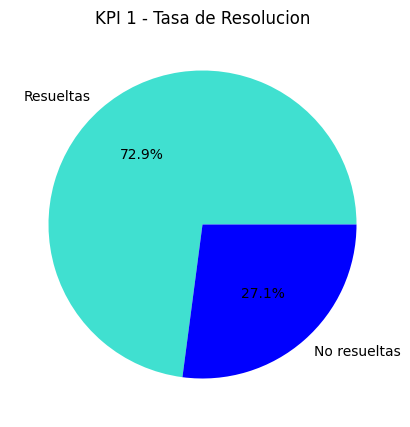

In [36]:
# Grafico de pastel para ver la proporcion
labels = ['Resueltas', 'No resueltas']
valores = [resueltas, no_resueltas]
colores = ['turquoise', 'blue']

plt.figure(figsize=(5,5))
plt.pie(valores, labels=labels, colors=colores, autopct='%1.1f%%')
plt.title('KPI 1 - Tasa de Resolucion')
plt.show()

**Resultado KPI 1:** CR = 72.92%

**Interpretación:** El 72.92% de las llamadas se resolvieron en el primer contacto, lo que significa que casi 3 de cada 4 clientes no necesitan volver a llamar, esto evidencia que los sistemas de soporte están proporcionando suficiente información para resolver los requerimientos de los clientes. Sin embargo el 27,08% quedó sin resolver, esto podria mejorar mediante estrategias de capacitación.

## KPI 2 - Tiempo Promedio de Respuesta (ASA - Average Speed of Answer)

### Cálculo Matemático/Lógico
ASA = Σ(Tiempo de Espera) / Número de Llamadas Atendidas

In [37]:
ASA = df['Speed of answer in seconds'].mean()
print(f'Velocidad Promedio de Respuesta = {ASA:.2f} segundos')
print(f'Eso es aproximadamente {ASA/60:.1f} minutos')

Velocidad Promedio de Respuesta = 67.52 segundos
Eso es aproximadamente 1.1 minutos


Agent
Becky      65.33
Stewart    66.18
Diane      66.27
Jim        66.34
Dan        67.28
Greg       68.44
Martha     69.49
Joe        70.99
Name: Speed of answer in seconds, dtype: float64


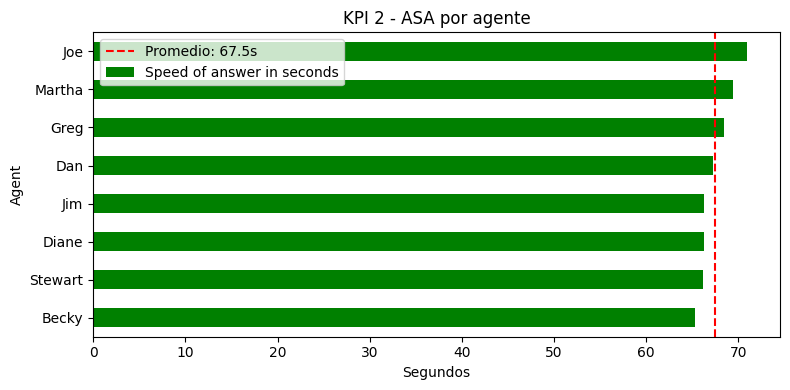

In [40]:
# Veo el ASA por agente
asa_por_agente = df.groupby('Agent')['Speed of answer in seconds'].mean().round(2)
asa_por_agente = asa_por_agente.sort_values()

print(asa_por_agente)

plt.figure(figsize=(8,4))
asa_por_agente.plot(kind='barh', color='green')
plt.axvline(ASA, color='red', linestyle='--', label=f'Promedio: {ASA:.1f}s')
plt.title('KPI 2 - ASA por agente')
plt.xlabel('Segundos')
plt.legend()
plt.tight_layout()
plt.show()

**Resultado KPI 2: ASA = 67.52 segundos**

**Interpretación:** En promedio los clientes esperan 67 segundos antes de hablar con un agente. Esto puede estar causando que los clientes cuelguen antes de ser atendidos y explica la alta tasa de abandono. Se debería realizar una mejora en los sistemas y procesos de gestión de llamadas para que el servicio sea más eficiente.

## KPI 3 - Nivel de Satisfaccion del Cliente (CSAT Promedio)

### Cálculo Matemático/Lógico
CSAT = Σ(Calificaciones de Satisfacción) / Número de Encuestas

In [ ]:
CSAT = df['Satisfaction rating'].mean()
print(f'CSAT promedio = {CSAT:.2f} de 5')

CSAT promedio = 3.40 de 5


Satisfaction rating
1.0     417
2.0     396
3.0    1218
4.0    1180
5.0     843
Name: count, dtype: int64


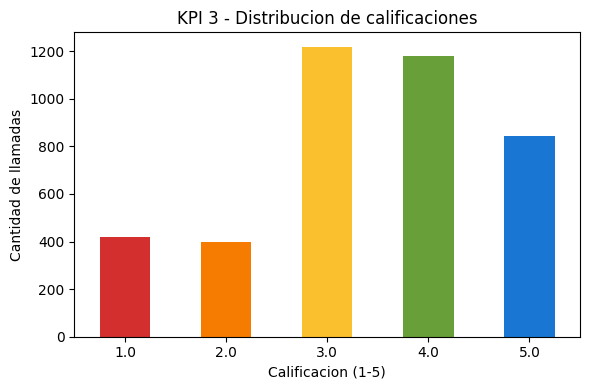

In [ ]:
# Distribucion de calificaciones
distribucion = df['Satisfaction rating'].value_counts().sort_index()
print(distribucion)

plt.figure(figsize=(6,4))
distribucion.plot(kind='bar', color=['#d32f2f','#f57c00','#fbc02d','#689f38','#1976d2'], rot=0)
plt.title('KPI 3 - Distribucion de calificaciones')
plt.xlabel('Calificacion (1-5)')
plt.ylabel('Cantidad de llamadas')
plt.tight_layout()
plt.show()

In [ ]:
# CSAT por agente
csat_agente = df.groupby('Agent')['Satisfaction rating'].mean().round(2).sort_values(ascending=False)
print(csat_agente)

Agent
Martha     3.47
Dan        3.45
Diane      3.41
Greg       3.40
Stewart    3.40
Jim        3.39
Becky      3.37
Joe        3.33
Name: Satisfaction rating, dtype: float64


**Resultado KPI 3:** CSAT = 3.40 / 5.00

**Interpretación:** La satisfaccion promedio es de 3.40 sobre 5, que equivale a un 68% de aprobacion. Ningun agente llega a 4.0, y la calificacion 3 es la mas frecuente, lo que sugiere que la mayoria de clientes tiene una experiencia "regular". Para mejorar esto se deberia reducir el tiempo de espera e incrementar la tasa de resolución en el primer contacto.

## KPI 4 - Volumen de Llamadas y Tasa de Abandono por Agente

### Cálculo Matemático/Lógico
Tasa de Abandono = (Llamadas No Contestadas / Total de Llamadas) × 100

In [ ]:
# Realizo una agrupacion por agente
kpi4 = df.groupby('Agent').agg(
    total = ('Call Id', 'count'),
    contestadas = ('Answered (Y/N)', lambda x: (x == 'Y').sum()),
    no_contestadas = ('Answered (Y/N)', lambda x: (x == 'N').sum())
)

kpi4['tasa_abandono'] = (kpi4['no_contestadas'] / kpi4['total'] * 100).round(2)

print(kpi4)

         total  contestadas  no_contestadas  tasa_abandono
Agent                                                     
Becky      631          517             114          18.07
Dan        633          523             110          17.38
Diane      633          501             132          20.85
Greg       624          502             122          19.55
Jim        666          536             130          19.52
Joe        593          484             109          18.38
Martha     638          514             124          19.44
Stewart    582          477             105          18.04


In [ ]:
tasa_global = (df['Answered (Y/N)'] == 'N').sum() / len(df) * 100
print(f'Tasa de abandono global: {tasa_global:.2f}%')

Tasa de abandono global: 18.92%


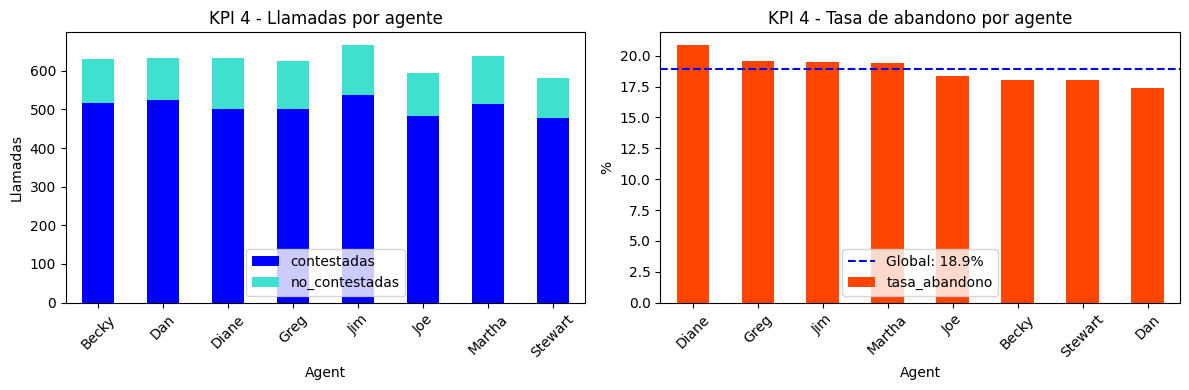

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Llamadas realizadas por agente
kpi4[['contestadas','no_contestadas']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['blue','turquoise'], rot=45
)
axes[0].set_title('KPI 4 - Llamadas por agente')
axes[0].set_ylabel('Llamadas')

# Tasa de abandono
kpi4['tasa_abandono'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='orangered', rot=45
)
axes[1].axhline(tasa_global, color='blue', linestyle='--', label=f'Global: {tasa_global:.1f}%')
axes[1].set_title('KPI 4 - Tasa de abandono por agente')
axes[1].set_ylabel('%')
axes[1].legend()

plt.tight_layout()
plt.show()

**Resultado KPI 4: Tasa de abandono global = 18.92%**

**Interpretación:** Casi 1 de cada 5 llamadas se pierde sin ser atendida. Diane tiene la peor tasa con 20.85% y Stewart la mejor con 18.04%. El volumen de llamadas esta bien distribuido entre los 8 agentes, entonces el problema no es que algun agente este sobrecargado sino que en general el equipo no tiene suficiente capacidad para atender toda la demanda. Esto mejoraría al optimizar los procesos de gestión de llamadas.